In [1]:
import re
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape

import numpy as np
from libpysal.weights import Queen

### Descarga datos renta

In [2]:
MUNICIPIOS = {
    "Valencia":  {"nombre": "Valencia",  "COD_MUNICIPIO": "46250", "natcode": "34104646250", "epsg": 25830, "tabla": 31250},
    "Barcelona": {"nombre": "Barcelona", "COD_MUNICIPIO": "08019", "natcode": "34090808019", "epsg": 25831, "tabla": 30896},
    "Murcia":    {"nombre": "Murcia",    "COD_MUNICIPIO": "30030", "natcode": "34143030030", "epsg": 25830, "tabla": 31115},
}

# Fechas (elige una opción o ninguna para descargarlo todo)
NULT = None                  # últimos N periodos, p. ej. 1
DESDE = "20240101"                 # "aaaammdd", p. ej. "20190101"
HASTA = "20241231"                 # "aaaammdd", p. ej. "20221231"

FORMATO_ANCHO = False        # True: una columna por serie
GUARDAR_CONJUNTO = False      # además de un CSV por municipio, uno con todos
# ------------------------------------------------

URL = "https://servicios.ine.es/wstempus/js/ES/DATOS_TABLA/{tabla}"
RE_SECCION = re.compile(r"\b(\d{10})\b")


def descargar(tabla, nult=None, desde=None, hasta=None):
    # tip=AM -> respuesta legible + metadatos de cada serie (variables y códigos)
    params = {"tip": "AM"}
    if nult:
        params["nult"] = nult
    if desde or hasta:
        params["date"] = f"{desde or ''}:{hasta or ''}"
    r = requests.get(URL.format(tabla=tabla), params=params, timeout=600)
    r.raise_for_status()
    return r.json()


def codigo_seccion(serie):
    """Devuelve el código de sección (10 dígitos) de una serie, o None."""
    for m in serie.get("MetaData", []) or []:
        cod = str(m.get("Codigo", "")).strip()
        if RE_SECCION.fullmatch(cod):
            return cod
    # Si no está en los metadatos, se busca en el nombre de la serie
    m = RE_SECCION.search(serie.get("Nombre", ""))
    return m.group(1) if m else None


def es_del_municipio(serie, cod_sec, muni):
    cod_mun = muni.get("COD_MUNICIPIO")
    if cod_mun and cod_sec:
        return cod_sec.startswith(cod_mun)
    # Alternativa por nombre si la serie no trae código de sección
    nombre = muni.get("nombre")
    if nombre:
        texto = serie.get("Nombre", "").lower()
        return nombre.lower() in texto and "secci" in texto
    return False


def convertir_fecha(col):
    """Acepta fechas ISO (tip=A) o milisegundos desde 1970."""
    if pd.api.types.is_numeric_dtype(col):
        f = pd.to_datetime(col, unit="ms", utc=True, errors="coerce")
    else:
        f = pd.to_datetime(col, utc=True, errors="coerce")
    return f.dt.tz_convert("Europe/Madrid").dt.date


def filtrar_municipio(data, clave, muni):
    """Devuelve un DataFrame con las secciones de un municipio (o vacío)."""
    filas = []
    for serie in data:
        cod_sec = codigo_seccion(serie)
        if not es_del_municipio(serie, cod_sec, muni):
            continue

        # Cada variable de la tabla (indicador, sexo, etc.) pasa a ser una columna
        dims = {}
        for m in serie.get("MetaData", []) or []:
            var = (m.get("Variable") or {}).get("Nombre", "Variable")
            dims[var] = m.get("Nombre")

        for d in serie.get("Data", []) or []:
            filas.append({
                "tabla": muni.get("tabla"),
                "municipio": clave,
                "cod_municipio": muni.get("COD_MUNICIPIO"),
                "natcode": muni.get("natcode"),
                "codigo_seccion": cod_sec,
                "distrito": cod_sec[5:7] if cod_sec else None,
                "seccion": cod_sec[7:10] if cod_sec else None,
                "serie": serie.get("Nombre"),
                **dims,
                "anyo": d.get("Anyo"),
                "periodo": d.get("T3_Periodo") or d.get("FK_Periodo"),
                "fecha": d.get("Fecha"),
                "valor": d.get("Valor"),
            })

    df = pd.DataFrame(filas)
    if df.empty:
        return df

    df["fecha"] = convertir_fecha(df["fecha"])
    return df.sort_values(["codigo_seccion", "serie", "fecha"]).reset_index(drop=True)


def a_formato_ancho(df):
    return (df.pivot_table(index=["tabla", "municipio", "cod_municipio", "natcode",
                                  "codigo_seccion", "anyo"],
                           columns="serie", values="valor")
              .reset_index())


def main():
    # Cada tabla se descarga una sola vez, aunque la usen varios municipios
    cache = {}
    resultados = {}

    for clave, muni in MUNICIPIOS.items():
        tabla = muni.get("tabla")
        if not tabla:
            print(f"[{clave}] sin tabla definida, se omite")
            continue

        if tabla not in cache:
            print(f"Descargando tabla {tabla}...")
            try:
                cache[tabla] = descargar(tabla, NULT, DESDE, HASTA)
            except requests.RequestException as e:
                print(f"    error al descargar la tabla {tabla}: {e}")
                cache[tabla] = []
            print(f"    {len(cache[tabla])} series recibidas")

        data = cache[tabla]
        df = filtrar_municipio(data, clave, muni)

        if df.empty:
            print(f"[{clave}] sin secciones en la tabla {tabla}")
            if data:
                print("    ejemplo de series para revisar el formato:")
                for s in data[:3]:
                    print("     -", s.get("Nombre"))
            continue

        print(f"[{clave}] {df['codigo_seccion'].nunique()} secciones, "
              f"{len(df)} filas, fechas {df['fecha'].min()} a {df['fecha'].max()}")

        salida = a_formato_ancho(df) if FORMATO_ANCHO else df
        archivo = f"/Users/aidavillalba/Desktop/Artículos/2026/02_Mediterranean cities/Datos/renta/tabla_{tabla}_secciones_{muni['COD_MUNICIPIO']}_{clave}.csv"
        salida.to_csv(archivo, index=False, encoding="utf-8-sig")
        print(f"    guardado en {archivo}")
        resultados[clave] = df

    if GUARDAR_CONJUNTO and len(resultados) > 1:
        todo = pd.concat(resultados.values(), ignore_index=True)
        salida = a_formato_ancho(todo) if FORMATO_ANCHO else todo
        archivo = "secciones_todos_municipios.csv"
        salida.to_csv(archivo, index=False, encoding="utf-8-sig")
        print(f"\nConjunto guardado en {archivo}")

    return resultados


if __name__ == "__main__":
    main()

Descargando tabla 31250...
    14898 series recibidas
[Valencia] sin secciones en la tabla 31250
    ejemplo de series para revisar el formato:
     - Ademuz. Dato base. Renta neta media por persona. 
     - Ademuz. Dato base. Renta neta media por hogar. 
     - Ademuz. Dato base. Media de la renta por unidad de consumo. 
Descargando tabla 30896...
    31458 series recibidas
[Barcelona] sin secciones en la tabla 30896
    ejemplo de series para revisar el formato:
     - Abrera. Dato base. Renta neta media por persona. 
     - Abrera. Dato base. Renta neta media por hogar. 
     - Abrera. Dato base. Media de la renta por unidad de consumo. 
Descargando tabla 31115...
    8094 series recibidas
[Murcia] sin secciones en la tabla 31115
    ejemplo de series para revisar el formato:
     - Murcia sección 02031. Dato base. Renta neta media por persona. 
     - Murcia sección 02031. Dato base. Renta neta media por hogar. 
     - Murcia sección 02031. Dato base. Media de la renta por unidad d

### Descarga shape secciones censales

In [3]:
def get_shape_secciones(ciudad):

    year=2022


    BASE_URL = (
    f"https://www.ine.es/geoserver/ogc/features/v1/collections/"
    f"WMS_INE_SECCIONES_G01:Secciones_{year}/items")

    params = {
        "f"          : "application/geo+json",
        "limit"      : 1500,
        "filter"     : f"CUSEC LIKE '{ciudad["COD_MUNICIPIO"]}%'",
        "filter-lang": "cql2-text",
        }


    resp = requests.get(BASE_URL, params=params, timeout=60)
    resp.raise_for_status()


    dict_aux = {
        feat["properties"]["CUSEC"]: feat["geometry"]
        for feat in resp.json()["features"]
    }

    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        {"CUSEC": list(dict_aux.keys())},
        geometry=[shape(geom) for geom in dict_aux.values()],
        crs="EPSG:4326",  
    ).to_crs("EPSG:{}".format(ciudad["epsg"])) 

    return gdf

### Unión

#### Shapes secciones con valores renta

In [4]:
gdf_sec_vlc = get_shape_secciones(MUNICIPIOS["Valencia"])
gdf_sec_bcn = get_shape_secciones(MUNICIPIOS["Barcelona"])
gdf_sec_mur = get_shape_secciones(MUNICIPIOS["Murcia"])

In [5]:
df_renta_vlc = pd.read_csv("/Users/aidavillalba/Desktop/Artículos/2026/02_Mediterranean cities/Datos/renta/tabla_31250_secciones_46250_Valencia.csv")
df_renta_bcn = pd.read_csv("/Users/aidavillalba/Desktop/Artículos/2026/02_Mediterranean cities/Datos/renta/tabla_30896_secciones_08019_Barcelona.csv")
df_renta_mur = pd.read_csv("/Users/aidavillalba/Desktop/Artículos/2026/02_Mediterranean cities/Datos/renta/tabla_31115_secciones_30030_Murcia.csv")

df_renta_vlc= df_renta_vlc[df_renta_vlc["Variable"] == "Mediana de la renta por unidad de consumo"][["codigo_seccion", "valor"]]
df_renta_bcn= df_renta_bcn[df_renta_bcn["Variable"] == "Mediana de la renta por unidad de consumo"][["codigo_seccion", "valor"]]
df_renta_mur= df_renta_mur[df_renta_mur["Variable"] == "Mediana de la renta por unidad de consumo"][["codigo_seccion", "valor"]]


df_renta_vlc["codigo_seccion"] = df_renta_vlc["codigo_seccion"].astype(str)
df_renta_bcn["codigo_seccion"] = df_renta_bcn["codigo_seccion"].astype(str)
df_renta_bcn["codigo_seccion"] = "0"+df_renta_bcn["codigo_seccion"]
df_renta_mur["codigo_seccion"] = df_renta_mur["codigo_seccion"].astype(str)

In [6]:
gdf_sec_vlc_renta = gdf_sec_vlc.merge(df_renta_vlc, how = "left", left_on= "CUSEC", right_on="codigo_seccion")
gdf_sec_bcn_renta = gdf_sec_bcn.merge(df_renta_bcn, how = "left", left_on= "CUSEC", right_on="codigo_seccion")
gdf_sec_mur_renta = gdf_sec_mur.merge(df_renta_mur, how = "left", left_on= "CUSEC", right_on="codigo_seccion")

#### Imputación valores ausentes

In [7]:
print(gdf_sec_vlc_renta[gdf_sec_vlc_renta["valor"].isna()].shape[0])
print(gdf_sec_bcn_renta[gdf_sec_bcn_renta["valor"].isna()].shape[0])
print(gdf_sec_mur_renta[gdf_sec_mur_renta["valor"].isna()].shape[0])

24
10
8


In [8]:


def imputar_ausentes (gdf):
    w = Queen.from_dataframe(gdf, use_index=False)
    gdf["imputado"] = gdf["valor"].isna()

    for _ in range(5):  # varias pasadas por si hay huecos contiguos
        vals = gdf["valor"].to_numpy(dtype=float)
        faltan = np.where(np.isnan(vals))[0]
        if len(faltan) == 0:
            break
        for i in faltan:
            vec = vals[w.neighbors[i]]
            vec = vec[~np.isnan(vec)]
            if len(vec):
                gdf.iat[i, gdf.columns.get_loc("valor")] = vec.mean()

    return gdf

In [9]:
#gdf_sec_vlc_imputado = imputar_ausentes(gdf_sec_vlc_renta)
#gdf_sec_bcn_imputado = imputar_ausentes(gdf_sec_bcn_renta)
#gdf_sec_mur_imputado = imputar_ausentes(gdf_sec_mur_renta)

In [10]:
#gdf_sec_vlc_renta.to_file("/Users/aidavillalba/Desktop/Artículos/2026/02_Mediterranean cities/Datos/renta/renta_secs_Valencia.geojson")
#gdf_sec_bcn_renta.to_file("/Users/aidavillalba/Desktop/Artículos/2026/02_Mediterranean cities/Datos/renta/renta_secs_Barcelona.geojson")
#gdf_sec_mur_renta.to_file("/Users/aidavillalba/Desktop/Artículos/2026/02_Mediterranean cities/Datos/renta/renta_secs_Murcia.geojson")

#### Valores renta por parcela catastral

In [11]:
df_2sfca_vlc = gpd.read_file("/Users/aidavillalba/Desktop/Artículos/2026/02_Mediterranean cities/resultados/Valencia/Valencia_2sfca.geojson")
df_2sfca_bcn = gpd.read_file("/Users/aidavillalba/Desktop/Artículos/2026/02_Mediterranean cities/resultados/Barcelona/Barcelona_2sfca.geojson")
df_2sfca_mur = gpd.read_file("/Users/aidavillalba/Desktop/Artículos/2026/02_Mediterranean cities/resultados/Murcia/Murcia_2sfca.geojson")

In [12]:
df_2sfca_vlc_renta = gpd.sjoin(df_2sfca_vlc, gdf_sec_vlc_renta, how="left", predicate="intersects")
df_2sfca_bcn_renta = gpd.sjoin(df_2sfca_bcn, gdf_sec_bcn_renta, how="left", predicate="intersects")
df_2sfca_mur_renta = gpd.sjoin(df_2sfca_mur, gdf_sec_mur_renta, how="left", predicate="intersects")

In [13]:
df_2sfca_vlc_renta_imputado = imputar_ausentes(df_2sfca_vlc_renta)
df_2sfca_bcn_renta_imputado = imputar_ausentes(df_2sfca_bcn_renta)
df_2sfca_mur_renta_imputado = imputar_ausentes(df_2sfca_mur_renta)

df_2sfca_vlc_renta_imputado.rename(columns={"valor":"renta"}, inplace=True)
df_2sfca_bcn_renta_imputado.rename(columns={"valor":"renta"}, inplace=True)
df_2sfca_mur_renta_imputado.rename(columns={"valor":"renta"}, inplace=True)



In [14]:

df_2sfca_vlc_renta_imputado = df_2sfca_vlc_renta_imputado[['nationalCa', 'Valencia_loc1_t15', 'Valencia_loc2_t15','Valencia_loc3_t15', 'Valencia_loc4_t15','renta', 'imputado', 'geometry',]]
df_2sfca_bcn_renta_imputado = df_2sfca_bcn_renta_imputado[['nationalCa', 'Barcelona_loc1_t15', 'Barcelona_loc2_t15','Barcelona_loc3_t15', 'Barcelona_loc4_t15','renta', 'imputado', 'geometry',]]
df_2sfca_mur_renta_imputado = df_2sfca_mur_renta_imputado[['nationalCa', 'Murcia_loc1_t15', 'Murcia_loc2_t15','Murcia_loc3_t15', 'Murcia_loc4_t15','renta', 'imputado', 'geometry',]]

In [15]:
df_2sfca_vlc_renta_imputado.to_file("/Users/aidavillalba/Desktop/Artículos/2026/02_Mediterranean cities/resultados/Valencia/Valencia_2sfca_renta.geojson")
df_2sfca_bcn_renta_imputado.to_file("/Users/aidavillalba/Desktop/Artículos/2026/02_Mediterranean cities/resultados/Barcelona/Barcelona_2sfca_renta.geojson")
df_2sfca_mur_renta_imputado.to_file("/Users/aidavillalba/Desktop/Artículos/2026/02_Mediterranean cities/resultados/Murcia/Murcia_2sfca_renta.geojson")

# Visualización

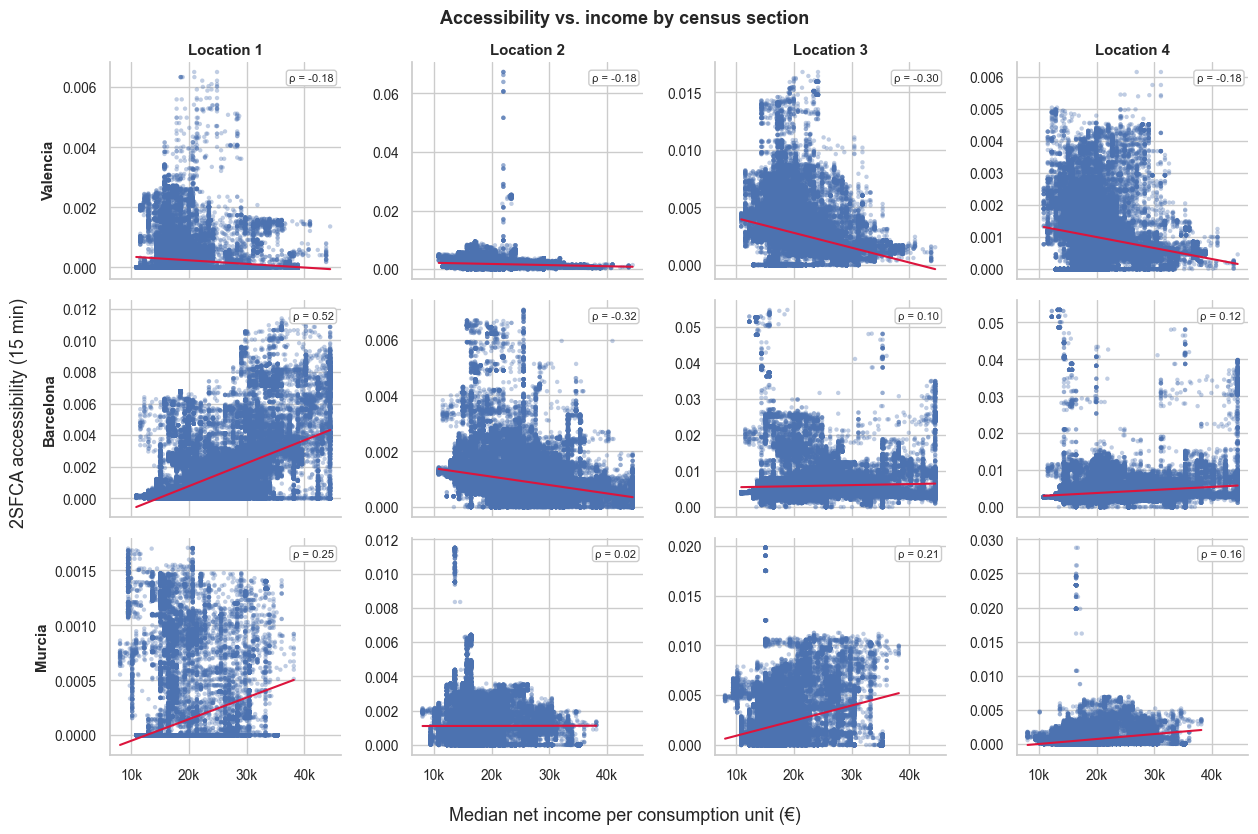

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr

# LOWESS trend line needs statsmodels; fall back to a linear fit without it
try:
    import statsmodels  # noqa: F401
    TREND = dict(lowess=True)
except ImportError:
    TREND = dict(ci=None)

# One row per city, one column per location
CIUDADES = {
    "Valencia":  df_2sfca_vlc_renta_imputado,
    "Barcelona": df_2sfca_bcn_renta_imputado,
    "Murcia":    df_2sfca_mur_renta_imputado,
}
LOCS = [1, 2, 3, 4]
UMBRAL = 15          # time threshold in minutes
X = "renta"

sns.set_theme(style="whitegrid", context="notebook", font_scale=0.9)
f, axes = plt.subplots(len(CIUDADES), len(LOCS), sharex=True, sharey=False,
                       figsize=(3.2 * len(LOCS), 2.8 * len(CIUDADES)),
                       squeeze=False)

for i, (ciudad, df) in enumerate(CIUDADES.items()):
    for j, loc in enumerate(LOCS):
        ax = axes[i, j]
        col = f"{ciudad}_loc{loc}_t{UMBRAL}"
        if col not in df.columns:
            ax.set_visible(False)
            continue

        sub = df[[X, col]].dropna()
        sns.regplot(data=sub, x=X, y=col, ax=ax, **TREND,
                    scatter_kws=dict(s=10, alpha=0.35, edgecolor="none"),
                    line_kws=dict(color="crimson", lw=1.5))

        # Spearman correlation in the corner of each panel
        rho = spearmanr(sub[X], sub[col])[0]
        ax.text(0.97, 0.95, f"ρ = {rho:.2f}", transform=ax.transAxes,
                ha="right", va="top", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8"))

        ax.set_xlabel("")
        ax.set_ylabel(ciudad if j == 0 else "", fontweight="bold")
        if i == 0:
            ax.set_title(f"Location {loc}", fontweight="bold")

# Income in thousands of euros on the bottom row
for ax in axes[-1]:
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))

f.supxlabel("Median net income per consumption unit (€)")
f.supylabel(f"2SFCA accessibility ({UMBRAL} min)")
f.suptitle("Accessibility vs. income by census section", fontweight="bold")
sns.despine(fig=f)
f.tight_layout()
plt.show()